In [2]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.7 MB/s eta 0:00:0000:01


In [15]:
import os
import json
import glob
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from sklearn.model_selection import GroupShuffleSplit
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pandas as pd
from concurrent.futures import ProcessPoolExecutor, as_completed 
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch.backends.cudnn as cudnn
import segmentation_models_pytorch as smp

# --- PyTorch Speed Optimizations ---
cudnn.benchmark = True 

# ==============================================================================
# 1. EXACT KAGGLE PATHS & HYPERPARAMETERS
# ==============================================================================
JSON_PATH = "/kaggle/input/datasets/ruturajkasture07/final-batch1-dataset/Labels1/Labels1/Balanced_Labels.json"
IMAGES_DIR = "/kaggle/input/datasets/ruturajkasture07/final-batch1-dataset/Images1/Images1"

MASK_OUT_DIR = "/kaggle/working/precomputed_masks"
BASE_SAVE_DIR = "/kaggle/working/phase1_results"
ANALYSIS_DIR = os.path.join(BASE_SAVE_DIR, "analysis")
MODEL_PREFIX = "ResUNet_V2"

os.makedirs(MASK_OUT_DIR, exist_ok=True)
os.makedirs(BASE_SAVE_DIR, exist_ok=True)
os.makedirs(ANALYSIS_DIR, exist_ok=True)

# Hyperparameters
IMAGE_SIZE = (512, 512)
BATCH_SIZE = 16 
EPOCHS = 30 
LR = 1e-4 
VAL_SPLIT = 0.15
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================================================================
# 2. ULTRA-FAST INDEXING & MULTIPROCESSING MASK GENERATION
# ==============================================================================
print(f"Loading JSON annotations...")
with open(JSON_PATH, "r") as f:
    annotations = json.load(f)

valid_extensions = ('.jpg', '.jpeg', '.png')
all_imgs = [os.path.join(dp, f) for dp, dn, filenames in os.walk(IMAGES_DIR) 
            for f in filenames if f.lower().endswith(valid_extensions)]
           
image_index = {os.path.splitext(os.path.basename(p))[0].lower(): p for p in all_imgs}
print(f"✅ Indexed {len(image_index)} total images.")

def process_single_mask(args):
    filename, data, img_path, mask_out_dir = args
    base_no_ext = os.path.splitext(os.path.basename(filename))[0].lower()
    mask_filename = base_no_ext + ".png"
    out_path = os.path.join(mask_out_dir, mask_filename)
    
    if os.path.exists(out_path): return True
    
    try:
        with Image.open(img_path) as img:
            width, height = img.size
    except Exception:
        return False

    mask = np.zeros((height, width), dtype=np.uint8)
    segmentations = data.get("segmentations", [])
    
    for seg_group in segmentations:
        for poly in seg_group:
            pts = np.array(poly, dtype=np.float32).reshape(-1, 2).astype(np.int32)
            cv2.fillPoly(mask, [pts], color=255) 
                
    Image.fromarray(mask).save(out_path)
    return True

def precompute_masks_fast():
    existing_masks = len(glob.glob(os.path.join(MASK_OUT_DIR, "*.png")))
    if existing_masks >= len(image_index) and existing_masks > 0:
        print("✅ Masks already pre-computed. Skipping generation...")
        return

    print("⚡ Starting Turbo Multiprocessing Mask Generation...")
    tasks = [(filename, data, image_index[os.path.splitext(os.path.basename(filename))[0].lower()], MASK_OUT_DIR) 
             for filename, data in annotations.items() if os.path.splitext(os.path.basename(filename))[0].lower() in image_index]
            
    cores = os.cpu_count() or 2
    with ProcessPoolExecutor(max_workers=cores) as executor:
        futures = {executor.submit(process_single_mask, t): t for t in tasks}
        for future in tqdm(as_completed(futures), total=len(tasks), desc=f"Generating with {cores} CPUs"):
            pass

precompute_masks_fast()

# ==============================================================================
# 3. PATIENT-LEVEL DATA SPLITTING (No Data Leakage)
# ==============================================================================
mask_files = glob.glob(os.path.join(MASK_OUT_DIR, "*.png"))
all_images = [image_index[os.path.splitext(os.path.basename(m))[0].lower()] for m in mask_files]

# Grouping by Patient ID (Assumes ID is the first part of filename before '_')
patient_groups = [os.path.basename(path).split('_')[0] for path in all_images]

gss = GroupShuffleSplit(n_splits=1, test_size=VAL_SPLIT, random_state=42)
train_idx, val_idx = next(gss.split(all_images, groups=patient_groups))

train_imgs = [all_images[i] for i in train_idx]
val_imgs = [all_images[i] for i in val_idx]

# ==============================================================================
# 4. DATASET WITH ALBUMENTATIONS (Added CLAHE)
# ==============================================================================
train_transform = A.Compose([
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.5), # Enhances X-ray contrast
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.7, border_mode=cv2.BORDER_CONSTANT),
    A.ElasticTransform(alpha=1, sigma=50, p=0.3), 
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.Affine(scale=(0.95, 1.05), translate_percent=(-0.05, 0.05), rotate=(-10, 10), p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

class FastScoliosisDatasetV2(Dataset):
    def __init__(self, image_paths, mask_dir, transform=None):
        self.image_paths = image_paths
        self.mask_dir = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        base_no_ext = os.path.splitext(os.path.basename(img_path))[0].lower()
        mask_path = os.path.join(self.mask_dir, base_no_ext + ".png")
        
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        image = cv2.resize(image, IMAGE_SIZE)
        mask = cv2.resize(mask, IMAGE_SIZE, interpolation=cv2.INTER_NEAREST)
        
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            
        mask = (mask > 127).float().unsqueeze(0)
        return image, mask

train_dataset = FastScoliosisDatasetV2(train_imgs, MASK_OUT_DIR, transform=train_transform)
val_dataset = FastScoliosisDatasetV2(val_imgs, MASK_OUT_DIR, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

# ==============================================================================
# 5. PRE-TRAINED ARCHITECTURE (Transfer Learning)
# ==============================================================================
model = smp.Unet(
    encoder_name="resnet34",        
    encoder_weights="imagenet",     
    in_channels=3,                  
    classes=1,                      
)

model = model.to(DEVICE)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

# ==============================================================================
# 6. COMBINED LOSS, METRICS, & SCHEDULER
# ==============================================================================
class DiceBCELoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceBCELoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, inputs, targets, smooth=1):
        bce_loss = self.bce(inputs, targets)
        inputs_sig = torch.sigmoid(inputs)
        inputs_flat = inputs_sig.view(-1)
        targets_flat = targets.view(-1)
        intersection = (inputs_flat * targets_flat).sum()
        dice_loss = 1 - ((2. * intersection + smooth) / (inputs_flat.sum() + targets_flat.sum() + smooth))
        return bce_loss + dice_loss

def calculate_metrics(preds, targets, threshold=0.5):
    preds_sig = torch.sigmoid(preds)
    preds_bin = (preds_sig > threshold).float()
    
    tp = (preds_bin * targets).sum()
    fp = (preds_bin * (1.0 - targets)).sum()
    fn = ((1.0 - preds_bin) * targets).sum()
    tn = ((1.0 - preds_bin) * (1.0 - targets)).sum()
    
    smooth = 1e-6
    accuracy = (tp + tn) / (tp + fp + fn + tn + smooth)
    precision = tp / (tp + fp + smooth)
    recall = tp / (tp + fn + smooth)
    f1 = (2.0 * precision * recall) / (precision + recall + smooth)
    dice = (2.0 * tp + smooth) / (preds_bin.sum() + targets.sum() + smooth)
    
    return accuracy.item(), precision.item(), recall.item(), f1.item(), dice.item()

optimizer = Adam(model.parameters(), lr=LR)
criterion = DiceBCELoss() 
scaler = torch.amp.GradScaler('cuda') 

# Learning Rate Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

# ==============================================================================
# 7. CHECKPOINTING & TRAINING LOOP
# ==============================================================================
CHECKPOINT_PATH = os.path.join(BASE_SAVE_DIR, "latest_checkpoint.pth")
START_EPOCH = 0

if os.path.exists(CHECKPOINT_PATH):
    print(f"🔄 Found checkpoint! Resuming training from: {CHECKPOINT_PATH}")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scaler.load_state_dict(checkpoint['scaler_state_dict'])
    
    # Load scheduler state if it exists in the checkpoint
    if 'scheduler_state_dict' in checkpoint:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        
    START_EPOCH = checkpoint['epoch'] + 1
    best_val_dice = checkpoint['best_val_dice']
    history = checkpoint['history']
    
    print(f"✅ Resuming at Epoch {START_EPOCH + 1} with Best Val Dice: {best_val_dice:.4f}")
else:
    print("🚀 Starting fresh training session.")
    best_val_dice = 0.0
    history = {
        'train_loss': [], 'val_loss': [], 
        'train_acc': [], 'val_acc': [],
        'train_prec': [], 'val_prec': [],
        'train_rec': [], 'val_rec': [],
        'train_f1': [], 'val_f1': [],
        'train_dice': [], 'val_dice': []
    }

print(f"Starting Phase 1 Training...")
for epoch in range(START_EPOCH, EPOCHS):
    model.train()
    train_loss, train_acc, train_prec, train_rec, train_f1, train_dice = 0, 0, 0, 0, 0, 0
    
    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'): 
            outputs = model(images)
            loss = criterion(outputs, masks)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item()
        acc, prec, rec, f1, dice = calculate_metrics(outputs, masks)
        train_acc += acc; train_prec += prec; train_rec += rec; train_f1 += f1; train_dice += dice

    model.eval()
    val_loss, val_acc, val_prec, val_rec, val_f1, val_dice = 0, 0, 0, 0, 0, 0
    
    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, masks)
            
            val_loss += loss.item()
            acc, prec, rec, f1, dice = calculate_metrics(outputs, masks)
            val_acc += acc; val_prec += prec; val_rec += rec; val_f1 += f1; val_dice += dice
            
    t_len, v_len = len(train_loader), len(val_loader)
    
    avg_t_loss, avg_v_loss = train_loss/t_len, val_loss/v_len
    avg_t_acc, avg_v_acc = train_acc/t_len, val_acc/v_len
    avg_t_prec, avg_v_prec = train_prec/t_len, val_prec/v_len
    avg_t_rec, avg_v_rec = train_rec/t_len, val_rec/v_len
    avg_t_f1, avg_v_f1 = train_f1/t_len, val_f1/v_len
    avg_t_dice, avg_v_dice = train_dice/t_len, val_dice/v_len
    
    # Record history
    history['train_loss'].append(avg_t_loss); history['val_loss'].append(avg_v_loss)
    history['train_acc'].append(avg_t_acc); history['val_acc'].append(avg_v_acc)
    history['train_prec'].append(avg_t_prec); history['val_prec'].append(avg_v_prec)
    history['train_rec'].append(avg_t_rec); history['val_rec'].append(avg_v_rec)
    history['train_f1'].append(avg_t_f1); history['val_f1'].append(avg_v_f1)
    history['train_dice'].append(avg_t_dice); history['val_dice'].append(avg_v_dice)
    
    # Step the learning rate scheduler based on validation dice
    scheduler.step(avg_v_dice)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"\nEpoch [{epoch+1}/{EPOCHS}] - LR: {current_lr:.6f}")
    print(f"Train -> Loss: {avg_t_loss:.4f} | Acc: {avg_t_acc:.4f} | Prec: {avg_t_prec:.4f} | Rec: {avg_t_rec:.4f} | F1: {avg_t_f1:.4f} | Dice: {avg_t_dice:.4f}")
    print(f"Val   -> Loss: {avg_v_loss:.4f} | Acc: {avg_v_acc:.4f} | Prec: {avg_v_prec:.4f} | Rec: {avg_v_rec:.4f} | F1: {avg_v_f1:.4f} | Dice: {avg_v_dice:.4f}")
    
    # Save the resumption checkpoint
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_dice': best_val_dice,
        'history': history
    }, CHECKPOINT_PATH)
    
    # Save the absolute best weights separately
    if avg_v_dice > best_val_dice:
        best_val_dice = avg_v_dice
        torch.save(model.state_dict(), os.path.join(BASE_SAVE_DIR, "best_model.pth"))
        print(f"  🌟 New best model saved! (Val Dice: {best_val_dice:.4f})\n")

# ==============================================================================
# 8. POST-TRAINING ANALYSIS & GRAPHS
# ==============================================================================
df_history = pd.DataFrame(history)
df_history.to_csv(os.path.join(ANALYSIS_DIR, f"{MODEL_PREFIX}_training_history.csv"), index=False)

print("\nGenerating Training Graphs...")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('ResNet34 U-Net Training & Validation Metrics', fontsize=20, fontweight='bold', y=1.02)
epochs_range = range(1, len(history['train_loss']) + 1)

# Graph 1: Loss
axes[0, 0].plot(epochs_range, history['train_loss'], label='Train Loss', color='blue')
axes[0, 0].plot(epochs_range, history['val_loss'], label='Val Loss', color='orange')
axes[0, 0].set_title('BCE + Dice Loss')
axes[0, 0].legend()

# Graph 2: Dice
axes[0, 1].plot(epochs_range, history['train_dice'], label='Train Dice', color='green')
axes[0, 1].plot(epochs_range, history['val_dice'], label='Val Dice', color='red')
axes[0, 1].set_title('Dice Coefficient')
axes[0, 1].legend()

# Graph 3: Accuracy
axes[0, 2].plot(epochs_range, history['train_acc'], label='Train Acc', color='purple')
axes[0, 2].plot(epochs_range, history['val_acc'], label='Val Acc', color='brown')
axes[0, 2].set_title('Pixel Accuracy')
axes[0, 2].legend()

# Graph 4: Precision
axes[1, 0].plot(epochs_range, history['train_prec'], label='Train Prec', color='teal')
axes[1, 0].plot(epochs_range, history['val_prec'], label='Val Prec', color='magenta')
axes[1, 0].set_title('Precision')
axes[1, 0].legend()

# Graph 5: Recall
axes[1, 1].plot(epochs_range, history['train_rec'], label='Train Rec', color='navy')
axes[1, 1].plot(epochs_range, history['val_rec'], label='Val Rec', color='darkorange')
axes[1, 1].set_title('Recall')
axes[1, 1].legend()

# Graph 6: F1 Score
axes[1, 2].plot(epochs_range, history['train_f1'], label='Train F1', color='olive')
axes[1, 2].plot(epochs_range, history['val_f1'], label='Val F1', color='cyan')
axes[1, 2].set_title('F1 Score')
axes[1, 2].legend()

plt.tight_layout()
graph_path = os.path.join(ANALYSIS_DIR, f"{MODEL_PREFIX}_all_metrics.png")
plt.savefig(graph_path, dpi=300, bbox_inches='tight') 
print(f"✅ Training Complete! Graphs saved to: {graph_path}")

AttributeError: module 'torch' has no attribute '_utils'

# *Version  2*

Loading JSON annotations...
# Indexed 2000 total images.
# Starting Turbo Multiprocessing Mask Generation...


Generating with 4 CPUs: 100%|██████████| 2000/2000 [00:05<00:00, 334.28it/s]


Training samples: 1700 | Validation samples: 300


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

...


Epoch [28/30] - Time: 2.78 mins - LR: 0.000050
Train -> Loss: 0.1332 | Acc: 0.9954 | Prec: 0.8615 | Rec: 0.8877 | F1: 0.8743 | Dice: 0.8743
Val   -> Loss: 0.1251 | Acc: 0.9957 | Prec: 0.8686 | Rec: 0.8959 | F1: 0.8820 | Dice: 0.8820
  # New best model saved! (Val Dice: 0.8820)



Epoch 29/30 [Val]: 100%|██████████| 75/75 [00:09<00:00,  8.33it/s]



Epoch [29/30] - Time: 2.78 mins - LR: 0.000050
Train -> Loss: 0.1316 | Acc: 0.9955 | Prec: 0.8635 | Rec: 0.8885 | F1: 0.8758 | Dice: 0.8758
Val   -> Loss: 0.1287 | Acc: 0.9955 | Prec: 0.8621 | Rec: 0.8957 | F1: 0.8786 | Dice: 0.8786


Epoch 30/30 [Val]: 100%|██████████| 75/75 [00:09<00:00,  8.30it/s]



Epoch [30/30] - Time: 2.77 mins - LR: 0.000050
Train -> Loss: 0.1303 | Acc: 0.9955 | Prec: 0.8648 | Rec: 0.8895 | F1: 0.8769 | Dice: 0.8769
Val   -> Loss: 0.1258 | Acc: 0.9956 | Prec: 0.8684 | Rec: 0.8946 | F1: 0.8812 | Dice: 0.8812

Generating Version 2 Training Graphs...
# Training Complete! Graphs saved to: /kaggle/working/phase2_results/analysis/EfficientNetB3_UNet_all_metrics.png


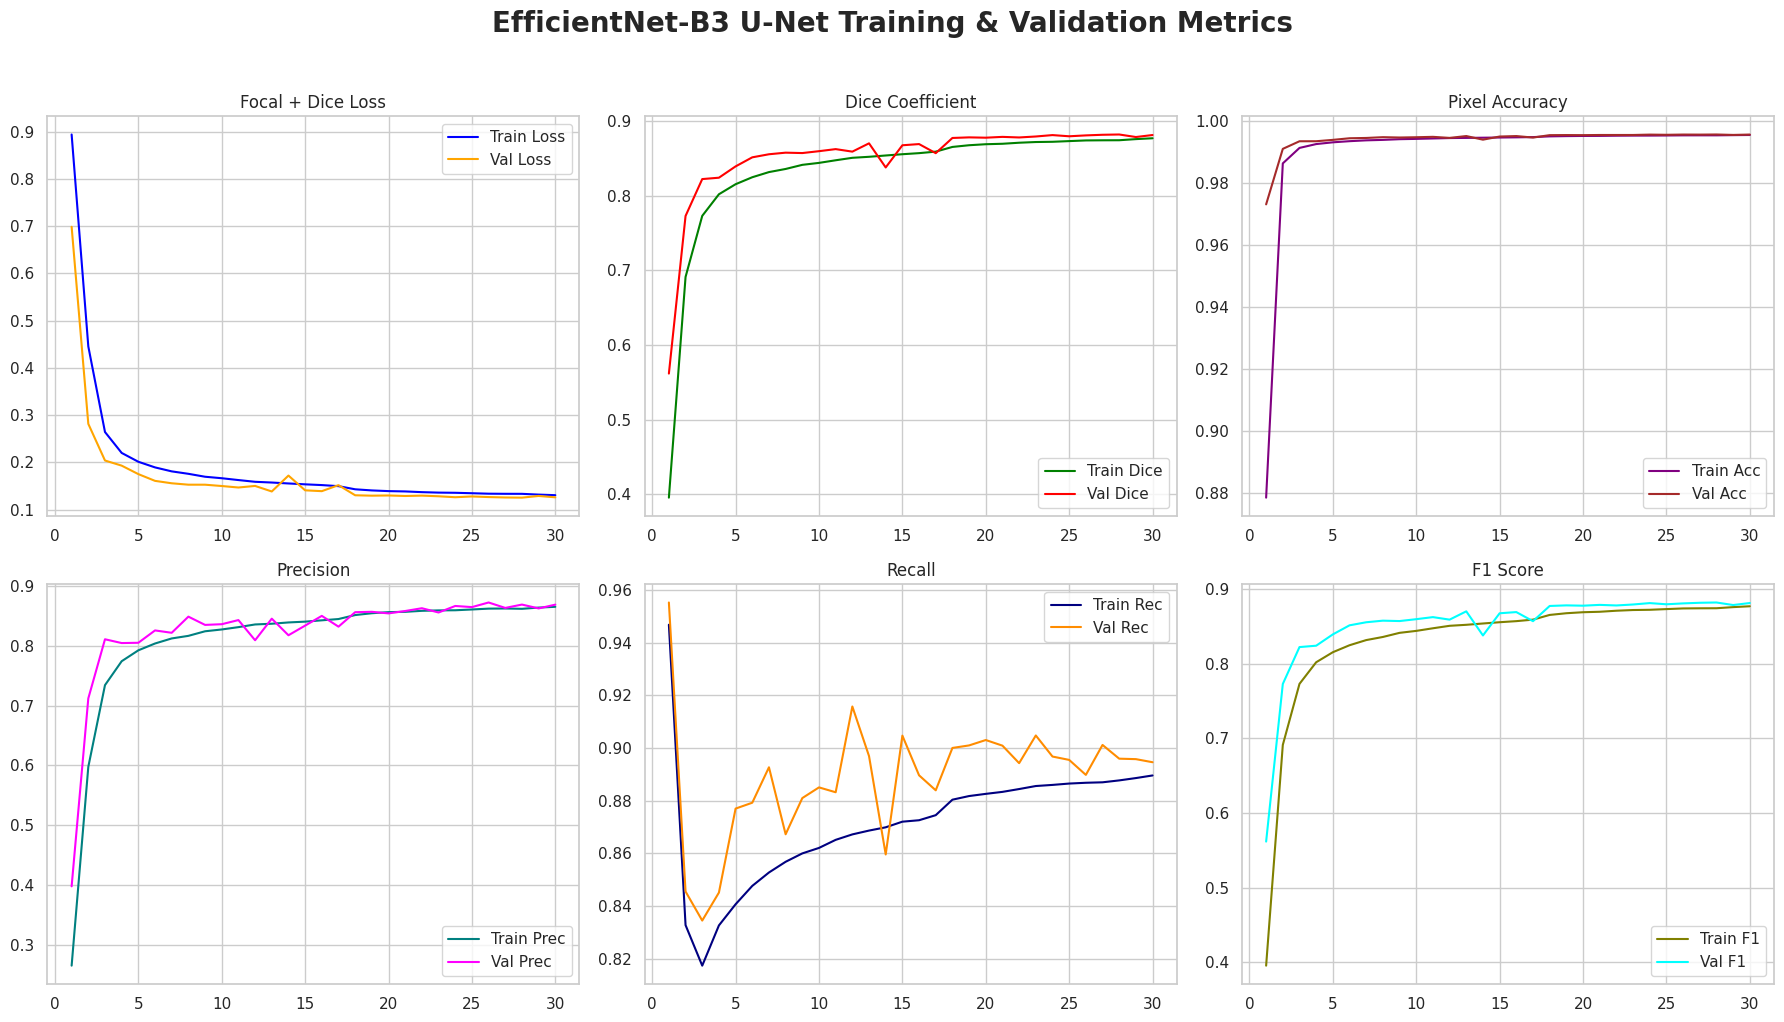

In [3]:
import os
import json
import glob
import cv2
import time
import numpy as np
import torch
import torch._utils  # ⚡ FIX: Forces PyTorch to load the missing utility module
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from sklearn.model_selection import GroupShuffleSplit
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pandas as pd
from concurrent.futures import ProcessPoolExecutor, as_completed 
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch.backends.cudnn as cudnn
import segmentation_models_pytorch as smp

# --- PyTorch Speed Optimizations ---
cudnn.benchmark = True 

# ==============================================================================
# 1. VERSION 2 KAGGLE PATHS & HYPERPARAMETERS
# ==============================================================================
JSON_PATH = "/kaggle/input/datasets/ruturajkasture07/final-batch1-dataset/Labels1/Labels1/Balanced_Labels.json"
IMAGES_DIR = "/kaggle/input/datasets/ruturajkasture07/final-batch1-dataset/Images1/Images1"

MASK_OUT_DIR = "/kaggle/working/precomputed_masks"
BASE_SAVE_DIR = "/kaggle/working/phase2_results"
ANALYSIS_DIR = os.path.join(BASE_SAVE_DIR, "analysis")
MODEL_PREFIX = "EfficientNetB3_UNet"

os.makedirs(MASK_OUT_DIR, exist_ok=True)
os.makedirs(BASE_SAVE_DIR, exist_ok=True)
os.makedirs(ANALYSIS_DIR, exist_ok=True)

IMAGE_SIZE = (768, 768) 
BATCH_SIZE = 4          
EPOCHS = 30 
LR = 1e-4 
VAL_SPLIT = 0.15
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================================================================
# 2. ULTRA-FAST INDEXING & MULTIPROCESSING MASK GENERATION
# ==============================================================================
print(f"Loading JSON annotations...")
with open(JSON_PATH, "r") as f:
    annotations = json.load(f)

valid_extensions = ('.jpg', '.jpeg', '.png')
all_imgs = [os.path.join(dp, f) for dp, dn, filenames in os.walk(IMAGES_DIR) 
            for f in filenames if f.lower().endswith(valid_extensions)]
           
image_index = {os.path.splitext(os.path.basename(p))[0].lower(): p for p in all_imgs}
print(f"# Indexed {len(image_index)} total images.")

def process_single_mask(args):
    filename, data, img_path, mask_out_dir = args
    base_no_ext = os.path.splitext(os.path.basename(filename))[0].lower()
    mask_filename = base_no_ext + ".png"
    out_path = os.path.join(mask_out_dir, mask_filename)
    
    if os.path.exists(out_path): return True
    
    try:
        with Image.open(img_path) as img:
            width, height = img.size
    except Exception:
        return False

    mask = np.zeros((height, width), dtype=np.uint8)
    segmentations = data.get("segmentations", [])
    
    for seg_group in segmentations:
        for poly in seg_group:
            pts = np.array(poly, dtype=np.float32).reshape(-1, 2).astype(np.int32)
            cv2.fillPoly(mask, [pts], color=255) 
                
    Image.fromarray(mask).save(out_path)
    return True

def precompute_masks_fast():
    existing_masks = len(glob.glob(os.path.join(MASK_OUT_DIR, "*.png")))
    if existing_masks >= len(image_index) and existing_masks > 0:
        print("# Masks already pre-computed. Skipping generation...")
        return

    print("# Starting Turbo Multiprocessing Mask Generation...")
    tasks = [(filename, data, image_index[os.path.splitext(os.path.basename(filename))[0].lower()], MASK_OUT_DIR) 
             for filename, data in annotations.items() if os.path.splitext(os.path.basename(filename))[0].lower() in image_index]
            
    cores = os.cpu_count() or 2
    with ProcessPoolExecutor(max_workers=cores) as executor:
        futures = {executor.submit(process_single_mask, t): t for t in tasks}
        for future in tqdm(as_completed(futures), total=len(tasks), desc=f"Generating with {cores} CPUs"):
            pass

precompute_masks_fast()

# ==============================================================================
# 3. PATIENT-LEVEL DATA SPLITTING
# ==============================================================================
mask_files = glob.glob(os.path.join(MASK_OUT_DIR, "*.png"))
all_images = [image_index[os.path.splitext(os.path.basename(m))[0].lower()] for m in mask_files]

patient_groups = [os.path.basename(path).split('_')[0] for path in all_images]

gss = GroupShuffleSplit(n_splits=1, test_size=VAL_SPLIT, random_state=42)
train_idx, val_idx = next(gss.split(all_images, groups=patient_groups))

train_imgs = [all_images[i] for i in train_idx]
val_imgs = [all_images[i] for i in val_idx]

# ==============================================================================
# 4. DATASET WITH CPU-OPTIMIZED ALBUMENTATIONS
# ==============================================================================
train_transform = A.Compose([
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.5), 
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.7, border_mode=cv2.BORDER_CONSTANT),
    # # Fixed GPU Starvation: Replaced ElasticTransform with GridDistortion
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3), 
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.Affine(scale=(0.95, 1.05), translate_percent=(-0.05, 0.05), rotate=(-10, 10), p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

class FastScoliosisDatasetV2(Dataset):
    def __init__(self, image_paths, mask_dir, transform=None):
        self.image_paths = image_paths
        self.mask_dir = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        base_no_ext = os.path.splitext(os.path.basename(img_path))[0].lower()
        mask_path = os.path.join(self.mask_dir, base_no_ext + ".png")
        
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        image = cv2.resize(image, IMAGE_SIZE)
        mask = cv2.resize(mask, IMAGE_SIZE, interpolation=cv2.INTER_NEAREST)
        
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            
        mask = (mask > 127).float().unsqueeze(0)
        return image, mask

train_dataset = FastScoliosisDatasetV2(train_imgs, MASK_OUT_DIR, transform=train_transform)
val_dataset = FastScoliosisDatasetV2(val_imgs, MASK_OUT_DIR, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

# ==============================================================================
# 5. PRE-TRAINED ARCHITECTURE & CONFIG EXPORT
# ==============================================================================
model = smp.Unet(
    encoder_name="efficientnet-b3", 
    encoder_weights="imagenet",     
    in_channels=3,                  
    classes=1,                      
)

# # Fixed Kaggle Slowdown: Removed DataParallel overhead for single-GPU efficiency
model = model.to(DEVICE)

# Save Comprehensive Model Configuration for Comparisons
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

config_dict = {
    "Model_Architecture": "U-Net",
    "Encoder": "EfficientNet-B3",
    "Encoder_Weights": "ImageNet Pre-trained",
    "Total_Parameters": total_params,
    "Trainable_Parameters": trainable_params,
    "Image_Resolution": IMAGE_SIZE,
    "Batch_Size": BATCH_SIZE,
    "Epochs": EPOCHS,
    "Learning_Rate_Init": LR,
    "Optimizer": "Adam",
    "Loss_Function": "Focal (alpha=0.25, gamma=2.0) + Dice",
    "LR_Scheduler": "ReduceLROnPlateau (factor=0.5, patience=3)",
    "Training_Samples": len(train_dataset),
    "Validation_Samples": len(val_dataset)
}

with open(os.path.join(ANALYSIS_DIR, f"{MODEL_PREFIX}_config.json"), 'w') as f:
    json.dump(config_dict, f, indent=4)
print(f"# Model Configuration saved. Total Params: {total_params:,}")

# ==============================================================================
# 6. FOCAL + DICE LOSS & METRICS
# ==============================================================================
class FocalDiceLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, smooth=1e-6):
        super(FocalDiceLoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss(reduction='none')
        self.alpha = alpha
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        bce_exp = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - bce_exp) ** self.gamma * bce_loss
        focal_loss = focal_loss.mean()
        
        inputs_sig = torch.sigmoid(inputs)
        inputs_flat = inputs_sig.view(-1)
        targets_flat = targets.view(-1)
        intersection = (inputs_flat * targets_flat).sum()
        dice_loss = 1 - ((2. * intersection + self.smooth) / (inputs_flat.sum() + targets_flat.sum() + self.smooth))
        
        return focal_loss + dice_loss

def calculate_metrics(preds, targets, threshold=0.5):
    preds_sig = torch.sigmoid(preds)
    preds_bin = (preds_sig > threshold).float()
    
    tp = (preds_bin * targets).sum()
    fp = (preds_bin * (1.0 - targets)).sum()
    fn = ((1.0 - preds_bin) * targets).sum()
    tn = ((1.0 - preds_bin) * (1.0 - targets)).sum()
    
    smooth = 1e-6
    accuracy = (tp + tn) / (tp + fp + fn + tn + smooth)
    precision = tp / (tp + fp + smooth)
    recall = tp / (tp + fn + smooth)
    f1 = (2.0 * precision * recall) / (precision + recall + smooth)
    dice = (2.0 * tp + smooth) / (preds_bin.sum() + targets.sum() + smooth)
    
    return accuracy.item(), precision.item(), recall.item(), f1.item(), dice.item()

optimizer = Adam(model.parameters(), lr=LR)
criterion = FocalDiceLoss() 
scaler = torch.amp.GradScaler('cuda') 

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

# ==============================================================================
# 7. CHECKPOINTING & TRAINING LOOP WITH TIMING
# ==============================================================================
CHECKPOINT_PATH = os.path.join(BASE_SAVE_DIR, "latest_checkpoint_v2.pth")
START_EPOCH = 0

if os.path.exists(CHECKPOINT_PATH):
    print(f"# Found checkpoint! Resuming training from: {CHECKPOINT_PATH}")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scaler.load_state_dict(checkpoint['scaler_state_dict'])
    if 'scheduler_state_dict' in checkpoint:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        
    START_EPOCH = checkpoint['epoch'] + 1
    best_val_dice = checkpoint['best_val_dice']
    history = checkpoint['history']
    print(f"# Resuming at Epoch {START_EPOCH + 1} with Best Val Dice: {best_val_dice:.4f}")
else:
    print("# Starting fresh Version 2 training session.")
    best_val_dice = 0.0
    history = {
        'train_loss': [], 'val_loss': [], 
        'train_acc': [], 'val_acc': [],
        'train_prec': [], 'val_prec': [],
        'train_rec': [], 'val_rec': [],
        'train_f1': [], 'val_f1': [],
        'train_dice': [], 'val_dice': [],
        'epoch_time_mins': [] # Added for efficiency comparisons
    }

print(f"Starting Phase 2 Training (EfficientNet-B3 + Focal Loss)...")
for epoch in range(START_EPOCH, EPOCHS):
    start_time = time.time()
    
    model.train()
    train_loss, train_acc, train_prec, train_rec, train_f1, train_dice = 0, 0, 0, 0, 0, 0
    
    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'): 
            outputs = model(images)
            loss = criterion(outputs, masks)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item()
        acc, prec, rec, f1, dice = calculate_metrics(outputs, masks)
        train_acc += acc; train_prec += prec; train_rec += rec; train_f1 += f1; train_dice += dice

    model.eval()
    val_loss, val_acc, val_prec, val_rec, val_f1, val_dice = 0, 0, 0, 0, 0, 0
    
    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, masks)
            
            val_loss += loss.item()
            acc, prec, rec, f1, dice = calculate_metrics(outputs, masks)
            val_acc += acc; val_prec += prec; val_rec += rec; val_f1 += f1; val_dice += dice
            
    # Time Calculation
    epoch_duration = (time.time() - start_time) / 60.0
    
    t_len, v_len = len(train_loader), len(val_loader)
    avg_t_loss, avg_v_loss = train_loss/t_len, val_loss/v_len
    avg_t_acc, avg_v_acc = train_acc/t_len, val_acc/v_len
    avg_t_prec, avg_v_prec = train_prec/t_len, val_prec/v_len
    avg_t_rec, avg_v_rec = train_rec/t_len, val_rec/v_len
    avg_t_f1, avg_v_f1 = train_f1/t_len, val_f1/v_len
    avg_t_dice, avg_v_dice = train_dice/t_len, val_dice/v_len
    
    history['train_loss'].append(avg_t_loss); history['val_loss'].append(avg_v_loss)
    history['train_acc'].append(avg_t_acc); history['val_acc'].append(avg_v_acc)
    history['train_prec'].append(avg_t_prec); history['val_prec'].append(avg_v_prec)
    history['train_rec'].append(avg_t_rec); history['val_rec'].append(avg_v_rec)
    history['train_f1'].append(avg_t_f1); history['val_f1'].append(avg_v_f1)
    history['train_dice'].append(avg_t_dice); history['val_dice'].append(avg_v_dice)
    history['epoch_time_mins'].append(epoch_duration)
    
    scheduler.step(avg_v_dice)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"\nEpoch [{epoch+1}/{EPOCHS}] - Time: {epoch_duration:.2f} mins - LR: {current_lr:.6f}")
    print(f"Train -> Loss: {avg_t_loss:.4f} | Acc: {avg_t_acc:.4f} | Prec: {avg_t_prec:.4f} | Rec: {avg_t_rec:.4f} | F1: {avg_t_f1:.4f} | Dice: {avg_t_dice:.4f}")
    print(f"Val   -> Loss: {avg_v_loss:.4f} | Acc: {avg_v_acc:.4f} | Prec: {avg_v_prec:.4f} | Rec: {avg_v_rec:.4f} | F1: {avg_v_f1:.4f} | Dice: {avg_v_dice:.4f}")
    
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_dice': best_val_dice,
        'history': history
    }, CHECKPOINT_PATH)
    
    if avg_v_dice > best_val_dice:
        best_val_dice = avg_v_dice
        torch.save(model.state_dict(), os.path.join(BASE_SAVE_DIR, "best_model_v2.pth"))
        print(f"  # New best model saved! (Val Dice: {best_val_dice:.4f})\n")

# ==============================================================================
# 8. POST-TRAINING ANALYSIS & GRAPHS
# ==============================================================================
df_history = pd.DataFrame(history)
df_history.to_csv(os.path.join(ANALYSIS_DIR, f"{MODEL_PREFIX}_training_history.csv"), index=False)

print("\nGenerating Version 2 Training Graphs...")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EfficientNet-B3 U-Net Training & Validation Metrics', fontsize=20, fontweight='bold', y=1.02)
epochs_range = range(1, len(history['train_loss']) + 1)

axes[0, 0].plot(epochs_range, history['train_loss'], label='Train Loss', color='blue')
axes[0, 0].plot(epochs_range, history['val_loss'], label='Val Loss', color='orange')
axes[0, 0].set_title('Focal + Dice Loss')
axes[0, 0].legend()

axes[0, 1].plot(epochs_range, history['train_dice'], label='Train Dice', color='green')
axes[0, 1].plot(epochs_range, history['val_dice'], label='Val Dice', color='red')
axes[0, 1].set_title('Dice Coefficient')
axes[0, 1].legend()

axes[0, 2].plot(epochs_range, history['train_acc'], label='Train Acc', color='purple')
axes[0, 2].plot(epochs_range, history['val_acc'], label='Val Acc', color='brown')
axes[0, 2].set_title('Pixel Accuracy')
axes[0, 2].legend()

axes[1, 0].plot(epochs_range, history['train_prec'], label='Train Prec', color='teal')
axes[1, 0].plot(epochs_range, history['val_prec'], label='Val Prec', color='magenta')
axes[1, 0].set_title('Precision')
axes[1, 0].legend()

axes[1, 1].plot(epochs_range, history['train_rec'], label='Train Rec', color='navy')
axes[1, 1].plot(epochs_range, history['val_rec'], label='Val Rec', color='darkorange')
axes[1, 1].set_title('Recall')
axes[1, 1].legend()

axes[1, 2].plot(epochs_range, history['train_f1'], label='Train F1', color='olive')
axes[1, 2].plot(epochs_range, history['val_f1'], label='Val F1', color='cyan')
axes[1, 2].set_title('F1 Score')
axes[1, 2].legend()

plt.tight_layout()
graph_path = os.path.join(ANALYSIS_DIR, f"{MODEL_PREFIX}_all_metrics.png")
plt.savefig(graph_path, dpi=300, bbox_inches='tight') 
print(f"# Training Complete! Graphs saved to: {graph_path}")

In [7]:

import shutil
# Zips the entire /kaggle/working directory
shutil.make_archive('output_files', 'zip', '/kaggle/working/phase2_results')

from IPython.display import FileLink
FileLink(r'output_files.zip')

/kaggle/working/output_files.zip

# *The Code: Inference & Post-Processing Script*

Detected 16 vertebrae.
Vertebra 1 Coordinates:
  -> x: 290, y: 457
  -> x: 249, y: 449
  -> x: 255, y: 421
  -> x: 296, y: 428
Vertebra 2 Coordinates:
  -> x: 300, y: 415
  -> x: 260, y: 412
  -> x: 262, y: 384
  -> x: 302, y: 386
Vertebra 3 Coordinates:
  -> x: 265, y: 374
  -> x: 260, y: 348
  -> x: 295, y: 341
  -> x: 300, y: 367
Vertebra 4 Coordinates:
  -> x: 257, y: 338
  -> x: 246, y: 315
  -> x: 278, y: 301
  -> x: 288, y: 325
Vertebra 5 Coordinates:
  -> x: 242, y: 304
  -> x: 231, y: 282
  -> x: 260, y: 268
  -> x: 270, y: 289
Vertebra 6 Coordinates:
  -> x: 224, y: 274
  -> x: 215, y: 252
  -> x: 243, y: 241
  -> x: 252, y: 263
Vertebra 7 Coordinates:
  -> x: 215, y: 238
  -> x: 213, y: 214
  -> x: 238, y: 212
  -> x: 240, y: 235
Vertebra 8 Coordinates:
  -> x: 239, y: 205
  -> x: 216, y: 201
  -> x: 219, y: 182
  -> x: 242, y: 186
Vertebra 9 Coordinates:
  -> x: 243, y: 180
  -> x: 219, y: 174
  -> x: 224, y: 156
  -> x: 247, y: 163
Vertebra 10 Coordinates:
  -> x: 251, y: 

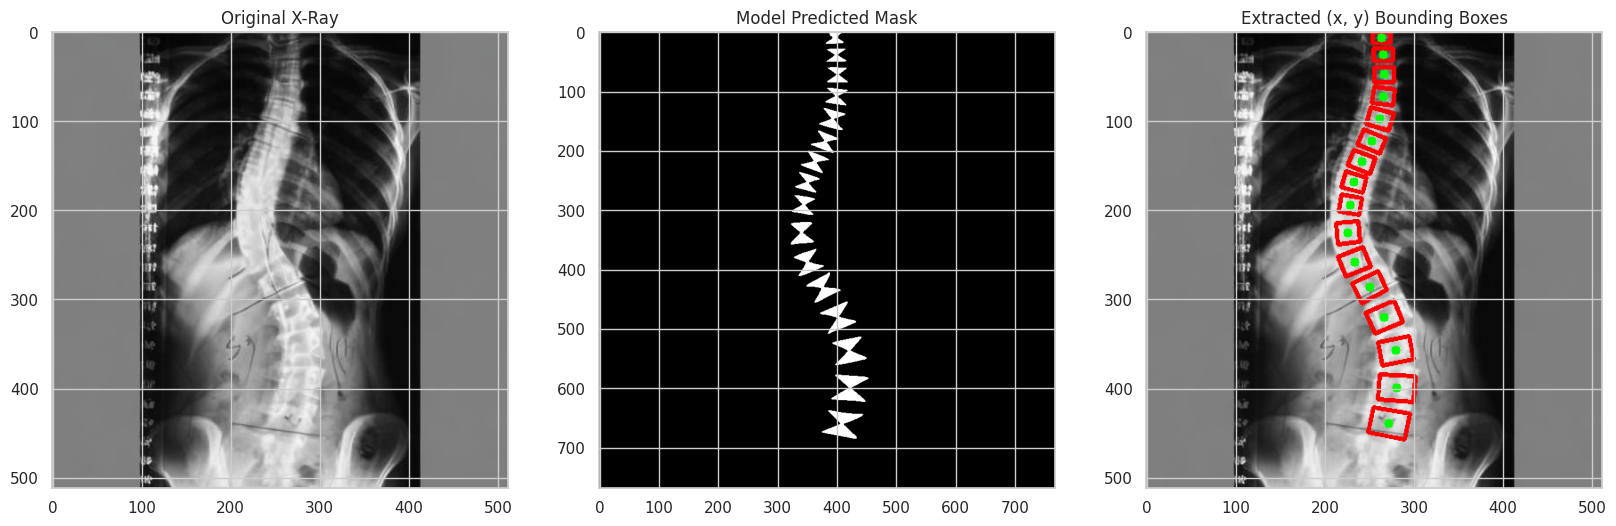

In [13]:


import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

# ==============================================================================
# 1. LOAD THE TRAINED MODEL
# ==============================================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = (768, 768)
MODEL_WEIGHTS = "/kaggle/working/phase2_results/best_model_v2.pth"

# Initialize identical architecture
model = smp.Unet(
    encoder_name="efficientnet-b3", 
    encoder_weights=None, # We don't need ImageNet weights anymore, we have yours!
    in_channels=3,                  
    classes=1,                      
)

# Load your custom weights
model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location=DEVICE))
model = model.to(DEVICE)
model.eval() # Set to evaluation mode

# Preprocessing pipeline (must match training exactly, minus augmentations)
val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# ==============================================================================
# 2. THE POST-PROCESSING FUNCTION (Mask -> Coordinates)
# ==============================================================================
def extract_vertebrae_coordinates(image_path, min_area=200):
    """
    Takes an image path, runs the UNet to get the mask, and uses OpenCV 
    to extract 4 (x,y) coordinates for every detected vertebra.
    """
    # 1. Load and resize image
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    orig_h, orig_w = img_rgb.shape[:2]
    
    img_resized = cv2.resize(img_rgb, IMAGE_SIZE)
    
    # 2. Prepare tensor and run inference
    tensor_img = val_transform(image=img_resized)['image'].unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            pred_mask = model(tensor_img)
            
    # Apply sigmoid to convert logits to probabilities, then threshold at 0.5
    pred_prob = torch.sigmoid(pred_mask).squeeze().cpu().numpy()
    binary_mask = (pred_prob > 0.5).astype(np.uint8) * 255
    
    # 3. OpenCV Post-Processing
    # Find all isolated white blobs
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    scale_x = orig_w / IMAGE_SIZE[0]
    scale_y = orig_h / IMAGE_SIZE[1]
    
    vertebrae_data = []
    vis_img = img_rgb.copy() # Copy of original image for drawing
    
    for cnt in contours:
        # Ignore tiny specks of noise that the model might have misclassified
        if cv2.contourArea(cnt) < min_area:
            continue
            
        # Get the tightest fitting rotated rectangle
        rect = cv2.minAreaRect(cnt)
        box = cv2.boxPoints(rect)
        
        # Scale coordinates back to the original image dimensions
        box[:, 0] = box[:, 0] * scale_x
        box[:, 1] = box[:, 1] * scale_y
        
        box = np.int32(box) # Convert to integer pixel coordinates
        
        # Save to our list
        vertebrae_data.append({
            "corners": box.tolist(),
            "center": [int(rect[0][0] * scale_x), int(rect[0][1] * scale_y)]
        })
        
        # Draw the red bounding box and center dot on the visualization image
        cv2.drawContours(vis_img, [box], 0, (255, 0, 0), 3) 
        cv2.circle(vis_img, (int(rect[0][0] * scale_x), int(rect[0][1] * scale_y)), 5, (0, 255, 0), -1)

    return vertebrae_data, vis_img, binary_mask

# ==============================================================================
# 3. TEST IT ON A SINGLE IMAGE
# ==============================================================================
# Swap this with a real path from your testing set!
TEST_IMAGE_PATH = "/kaggle/input/datasets/ruturajkasture07/testing1/016041.jpg" 

if os.path.exists(TEST_IMAGE_PATH):
    coords, drawn_image, mask = extract_vertebrae_coordinates(TEST_IMAGE_PATH)
    
    print(f"Detected {len(coords)} vertebrae.")
    for i, data in enumerate(coords):
        print(f"Vertebra {i+1} Coordinates:")
        for corner in data['corners']:
            print(f"  -> x: {corner[0]}, y: {corner[1]}")
            
    # Visualize the results
    fig, axes = plt.subplots(1, 3, figsize=(20, 10))
    axes[0].imshow(cv2.cvtColor(cv2.imread(TEST_IMAGE_PATH), cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original X-Ray")
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title("Model Predicted Mask")
    axes[2].imshow(drawn_image)
    axes[2].set_title("Extracted (x, y) Bounding Boxes")
    plt.show()
else:
    print("Please update TEST_IMAGE_PATH with a valid image path from your dataset to see the visualization.")